# ALGORITMOS DE ORDENAMIENTO

## IMPORTS

In [ ]:
import time #Mide Cuanto tarda en ejecutar algo
import random # Genera numeros aleatorios
import tracemalloc # Mide el uso de memoria del programa
import pandas as pd # Genera DataFrames
import matplotlib.pyplot as plt # Crea Graficos 

## ALGORITMOS DE ORDENAMIENTO
Ordenamiento 1: Este código sirve para ordenar una lista de números de menor a mayor usando el método bubble sort . Lo hace comparando números que están uno junto al otro y cambiándolos de lugar si están desordenados. Repite este proceso varias veces hasta que todos los números quedan en el orden correcto. Además, si en algún momento ve que ya no necesita hacer cambios, se detiene antes para no seguir trabajando innecesariamente.

Ordenamiento 2: Este código sirve para ordenar una lista de números usando el método Merge Sort. Lo que hace es dividir la lista en dos partes más pequeñas, luego vuelve a dividir esas partes hasta que cada una tenga solo un número (porque un solo número ya está ordenado). Después empieza a unir esas partes poco a poco, comparando los números y colocándolos en el orden correcto. Al final, devuelve la lista completa ya ordenada de menor a mayor.

Ordenamiento 3: Este código ordena una lista de números usando el método Quick Sort. Primero revisa si la lista tiene uno o ningún elemento; si es así, ya está ordenada. Luego elige un número como referencia (llamado pivote) y separa los demás números en dos grupos: los menores o iguales al pivote y los mayores. Después ordena esos dos grupos usando el mismo procedimiento y finalmente los une colocando primero los menores, luego el pivote y al final los mayores, obteniendo así la lista completa ordenada.

In [ ]:
# Ordenamiento 1
def bubble_sort(arr):
    n = len(arr)
    arr_copy = arr.copy()
    for i in range(n):
        swapped = False
        for j in range(0, n - i - 1):
            if arr_copy[j] > arr_copy[j + 1]:
                arr_copy[j], arr_copy[j + 1] = arr_copy[j + 1], arr_copy[j]
                swapped = True
        if not swapped:
            break
    return arr_copy

# Ordenamiento 2
def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left_half = merge_sort(arr[:mid])
    right_half = merge_sort(arr[mid:])
    return merge(left_half, right_half)


def merge(left, right):
    merged = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1
    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged

# Ordenamiento 3
def quick_sort(arr):
    if len(arr) <= 1:
        return arr.copy()
    pivot = arr[-1]
    items_lower = []
    items_greater = []
    for item in arr[:-1]:
        if item <= pivot:
            items_lower.append(item)
        else:
            items_greater.append(item)
    return quick_sort(items_lower) + [pivot] + quick_sort(items_greater)

## FUNCION PARA GENERAR ARREGLOS

In [8]:
def generate_test_array(size): # Genera un arreglo con numeros aleatorios entre 0 y 1,000,000
    return [random.randint(0, 10**6) for _ in range(size)] #Crea y devuelve una lista

## MEDICION DE TIEMPO Y MEMORIA
Este código sirve para medir cuánto tiempo tarda en ejecutarse un algoritmo de ordenamiento y cuánta memoria utiliza.

In [9]:
def measure_performance(sort_function, arr):
    tracemalloc.start()
    
    start_time = time.time()
    sort_function(arr)
    end_time = time.time()
    
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    execution_time = end_time - start_time
    memory_used = peak / (1024 * 1024)  # Convertir a MB
    
    return execution_time, memory_used

## PRUEBAS
Este código sirve para probar qué tan rápidos y cuánta memoria usan los diferentes algoritmos de ordenamiento con listas de distintos tamaños.

In [10]:
test_sizes = [10, 100, 1000, 10000, 100000, 1000000]

results = []

for size in test_sizes:
    print(f"\nProbando tamaño: {size}")
    test_arr = generate_test_array(size)
    
    # Bubble Sort (solo tamaños pequeños)
    if size <= 10000:
        time_bubble, mem_bubble = measure_performance(bubble_sort, test_arr)
        results.append(["Bubble Sort", size, time_bubble, mem_bubble])
    
    # Merge Sort
    time_merge, mem_merge = measure_performance(merge_sort, test_arr)
    results.append(["Merge Sort", size, time_merge, mem_merge])
    
    # Quick Sort
    time_quick, mem_quick = measure_performance(quick_sort, test_arr)
    results.append(["Quick Sort", size, time_quick, mem_quick])


Probando tamaño: 10

Probando tamaño: 100

Probando tamaño: 1000

Probando tamaño: 10000

Probando tamaño: 100000

Probando tamaño: 1000000


## TABLA DE RESULTADOS (DATAFRAME)

In [11]:
df = pd.DataFrame(results, columns=["Algoritmo", "Tamaño", "Tiempo (s)", "Memoria (MB)"])
df

,Algoritmo,Tamaño,Tiempo (s),Memoria (MB)
0,Bubble Sort,10,0.002525,0.000183
1,Merge Sort,10,0.000000,0.000259
2,Quick Sort,10,0.000000,0.000420
3,Bubble Sort,100,0.000500,0.000870
4,Merge Sort,100,0.000000,0.001732
5,Quick Sort,100,0.000501,0.005196
6,Bubble Sort,1000,0.373388,0.012056
7,Merge Sort,1000,0.003522,0.016449
8,Quick Sort,1000,0.002500,0.037621
9,Bubble Sort,10000,54.397226,0.080615


## GRAFICA DE TIEMPO
La imagen muestra una gráfica comparando el tiempo de ejecución de los tres algoritmos de ordenamiento: Bubble Sort (azul), Merge Sort (naranja) y Quick Sort (verde).

En el eje horizontal (abajo) está el tamaño del arreglo, que va desde 10 hasta 1,000,000 elementos.
En el eje vertical (lado izquierdo) está el tiempo en segundos que tarda cada algoritmo en ordenar.

### ¿Qué se observa?

Bubble Sort:
Funciona relativamente rápido con arreglos pequeños, pero cuando el tamaño llega a 10,000 elementos el tiempo aumenta muchísimo (más de 50 segundos). Esto muestra que es muy ineficiente para listas grandes.

Merge Sort:
Su tiempo aumenta de forma más gradual. Aunque tarda más que Quick Sort, sigue siendo mucho más eficiente que Bubble Sort para tamaños grandes.

Quick Sort:
Es el más rápido en casi todos los tamaños grandes. Su crecimiento en tiempo es mucho menor comparado con los otros.

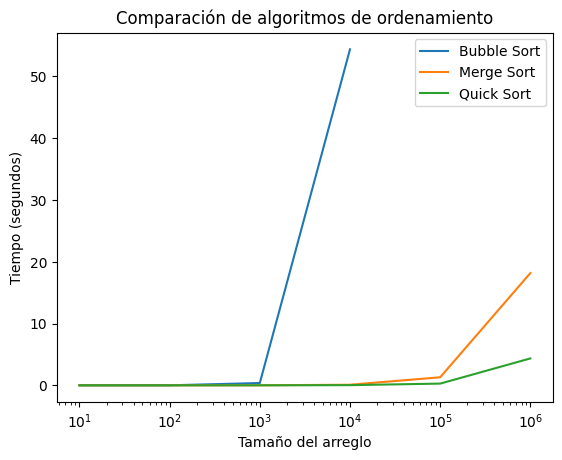

In [12]:
plt.figure()

for algorithm in df["Algoritmo"].unique():
    subset = df[df["Algoritmo"] == algorithm]
    plt.plot(subset["Tamaño"], subset["Tiempo (s)"], label=algorithm)

plt.xlabel("Tamaño del arreglo")
plt.ylabel("Tiempo (segundos)")
plt.title("Comparación de algoritmos de ordenamiento")
plt.legend()
plt.xscale("log")  # Escala logarítmica para que se vea mejor
plt.show()

## GRAFICA DE MEMORIA
Esta gráfica muestra el consumo de memoria (en MB) de los tres algoritmos de ordenamiento según el tamaño del arreglo.

En el eje horizontal está el tamaño del arreglo (desde 10 hasta 1,000,000 elementos).
En el eje vertical está la memoria utilizada en megabytes (MB).

### ¿Qué se observa?

Bubble Sort
Prácticamente no aparece con tamaños grandes porque no se ejecutó en listas muy grandes (es muy lento). Además, su consumo de memoria es bajo porque trabaja casi sobre la misma lista.

Merge Sort
Su consumo de memoria aumenta conforme crece el tamaño del arreglo. Esto ocurre porque necesita crear listas adicionales para dividir y luego unir los datos.

Quick Sort
Usa más memoria que Merge Sort en tamaños muy grandes (especialmente en 1,000,000 de elementos). Esto se debe a que crea listas nuevas para los elementos menores y mayores al pivote en cada llamada recursiva.

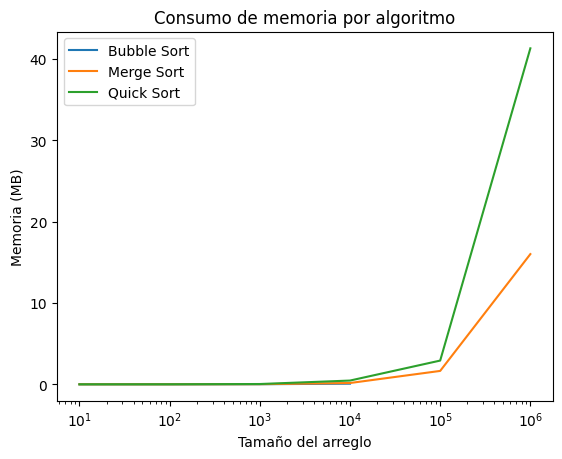

In [13]:
plt.figure()

for algorithm in df["Algoritmo"].unique():
    subset = df[df["Algoritmo"] == algorithm]
    plt.plot(subset["Tamaño"], subset["Memoria (MB)"], label=algorithm)

plt.xlabel("Tamaño del arreglo")
plt.ylabel("Memoria (MB)")
plt.title("Consumo de memoria por algoritmo")
plt.legend()
plt.xscale("log")
plt.show()